<a href="https://colab.research.google.com/github/LumocsNox/ML-foundations_skb/blob/master/CSE_422_project_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Welcome to the project**

Steps: First we would add the folder and the depression_data.csv inside the google colab notebook from where we would make the project work hopefully!

In [ ]:
#1
#Here are the libraries:
from google.colab import drive
import os


import pandas as pd
import numpy as np


import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc



In [ ]:
#2
# 1. Mounting Google Drive
working_directory= "/content/drive"
drive.mount(working_directory)

# 2. Setting up the Directory Path
project_folder_path = '/content/drive/MyDrive/datasets422'

# 3. Check if the path exists and list files to confirm the dataset is there
if os.path.exists(project_folder_path):
    os.chdir(project_folder_path)
    print(f">> Successfully changed directory to: {os.getcwd()}")
    print(">> Files in this folder:")
    print(os.listdir())
else:
    print(f">> Error: The path '{project_folder_path}' does not exist.")
    print("Please check your Google Drive folder structure and update the 'project_folder_path' variable.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
>> Successfully changed directory to: /content/drive/MyDrive/datasets422
>> Files in this folder:
['Depression_Data.csv']


In [ ]:
#3
# ===============================
# 1. Load the dataset
# ===============================

file_name = "Depression_Data.csv"  # change to .csv if needed

try:
    df = pd.read_csv(file_name)
    print(">> Dataset loaded successfully!")
except Exception as e:
    print(">> Error loading file:", e)
    raise


>> Dataset loaded successfully!


In [ ]:
#4
df

,1. Age,2. Gender,5. Academic Year,6. Current CGPA,7. Did you receive a waiver or scholarship at your university?,"1. In a semester, how often you felt nervous, anxious or on edge due to academic pressure?","2. In a semester, how often have you been unable to stop worrying about your academic affairs?","3. In a semester, how often have you had trouble relaxing due to academic pressure?","4. In a semester, how often have you been easily annoyed or irritated because of academic pressure?","5. In a semester, how often have you worried too much about academic affairs?",...,"2. In a semester, how often have you been feeling down, depressed or hopeless?","3. In a semester, how often have you had trouble falling or staying asleep, or sleeping too much?","4. In a semester, how often have you been feeling tired or having little energy?","5. In a semester, how often have you had poor appetite or overeating?","6. In a semester, how often have you been feeling bad about yourself - or that you are a failure or have let yourself or your family down?","7. In a semester, how often have you been having trouble concentrating on things, such as reading the books or watching television?","8. In a semester, how often have you moved or spoke too slowly for other people to notice? Or you've been moving a lot more than usual because you've been restless?","9. In a semester, how often have you had thoughts that you would be better off dead, or of hurting yourself?",Depression Value,Depression Label
0,18-22,Female,Fourth Year or Equivalent,2.50 - 2.99,No,1,1,1,2,2,...,2,1,1,2,1,1,1,1,11,Moderate Depression
1,18-22,Male,First Year or Equivalent,3.80 - 4.00,No,2,2,1,1,1,...,1,1,1,1,1,1,1,1,9,Mild Depression
2,18-22,Male,First Year or Equivalent,3.00 - 3.39,No,2,1,1,0,2,...,0,2,3,2,2,2,2,1,16,Moderately Severe Depression
3,18-22,Male,First Year or Equivalent,3.40 - 3.79,No,2,1,1,1,1,...,1,1,1,1,1,1,1,1,9,Mild Depression
4,18-22,Male,First Year or Equivalent,3.40 - 3.79,No,1,1,1,1,1,...,1,1,1,1,1,1,1,1,9,Mild Depression
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1972,23-26,Male,Fourth Year or Equivalent,3.40 - 3.79,No,1,2,2,2,2,...,2,1,2,2,1,1,1,1,13,Moderate Depression
1973,23-26,Female,Fourth Year or Equivalent,3.40 - 3.79,No,2,2,2,1,1,...,2,1,2,1,0,1,1,0,9,Mild Depression
1974,23-26,Female,Other,3.80 - 4.00,No,1,0,1,1,3,...,3,3,3,3,3,3,1,0,22,Severe Depression
1975,23-26,Male,Fourth Year or Equivalent,3.00 - 3.39,No,1,1,1,2,1,...,1,1,2,2,1,2,2,0,11,Moderate Depression


In [ ]:
#5
# ===============================
# 2. Basic dataset overview
# ===============================

print("\n================ DATASET OVERVIEW ================")
print(f"Shape (rows, columns): {df.shape}")

print("\n================ COLUMN NAMES ================")
print(df.columns.tolist())

print("\n================ DATA TYPES ================")
print(df.dtypes)

print("\n================ INFO() SUMMARY ================")
#Feature Names and its Datatypes
df.info()

# ===============================
# 3. Statistical descriptions
# ===============================

print("\n================ NUMERICAL DESCRIPTION ================")
print(df.describe())

print("\n================ CATEGORICAL DESCRIPTION ================")
print(df.describe(include='object'))

print("\n================ ALL COLUMNS DESCRIPTION ================")
print(df.describe(include='all'))




================ DATASET OVERVIEW ================
Shape (rows, columns): (1977, 37)

================ COLUMN NAMES ================
['1. Age', '2. Gender', '5. Academic Year', '6. Current CGPA', '7. Did you receive a waiver or scholarship at your university?', '1. In a semester, how often you felt nervous, anxious or on edge due to academic pressure? ', '2. In a semester, how often have you been unable to stop worrying about your academic affairs? ', '3. In a semester, how often have you had trouble relaxing due to academic pressure? ', '4. In a semester, how often have you been easily annoyed or irritated because of academic pressure?', '5. In a semester, how often have you worried too much about academic affairs? ', '6. In a semester, how often have you been so restless due to academic pressure that it is hard to sit still?', '7. In a semester, how often have you felt afraid, as if something awful might happen?', 'Anxiety Value', 'Anxiety Label', '1. In a semester, how often have y

In [ ]:
#6
# ===============================
# 4. Missing value analysis (COLUMNS)
# ===============================

missing_per_column = df.isna().sum()
missing_columns_count = (missing_per_column > 0).sum()

print("\n================ MISSING VALUES PER COLUMN ================")
print(df.isnull().sum())
print(missing_per_column[missing_per_column > 0])

print(f"\nNumber of columns with missing values: {missing_columns_count}")

# ===============================
# 5. Missing value analysis (ROWS)
# ===============================

missing_rows_count = df.isna().any(axis=1).sum()
total_rows = df.shape[0]
missing_rows_percentage = (missing_rows_count / total_rows) * 100

print("\n================ MISSING VALUES PER ROW ================")
print(f"Total rows: {total_rows}")
print(f"Rows with at least one missing value: {missing_rows_count}")
print(f"Percentage of rows with missing values: {missing_rows_percentage:.2f}%")

# ===============================
# 6. Final summary
# ===============================

print("\n================ FINAL SUMMARY ================")
print(f"Total columns: {df.shape[1]}")
print(f"Columns with missing values: {missing_columns_count}")
print(f"Total rows: {total_rows}")
print(f"Rows with missing values: {missing_rows_count}")
print(f"Missing rows percentage: {missing_rows_percentage:.2f}%")



================ MISSING VALUES PER COLUMN ================
1. Age                                                                                                                                                                   0
2. Gender                                                                                                                                                                6
5. Academic Year                                                                                                                                                         0
6. Current CGPA                                                                                                                                                          0
7. Did you receive a waiver or scholarship at your university?                                                                                                           0
1. In a semester, how often you felt nervous, anxious or on edge due to academic pre

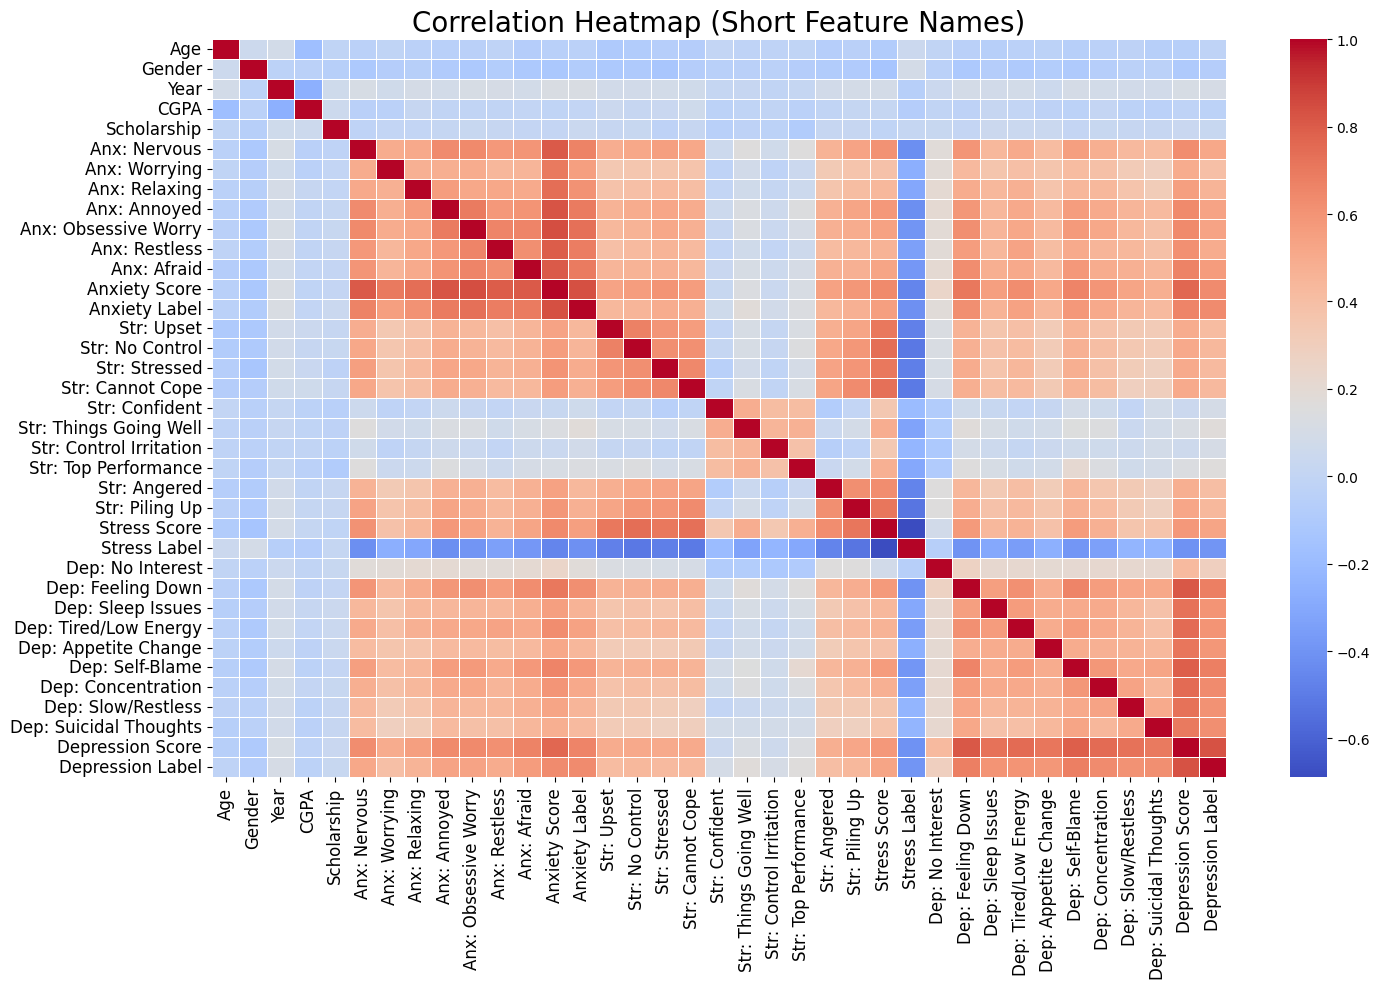

For making the heatmap more clear, we have decided to first map them with their shortened versions, and later on, we have used them to create the heatmap! Here are the mapping we have followed! Please refer to this mapping system to find your actual colomn value if you feel like you need it! 
Age <--- [ 1. Age ]
Gender <--- [ 2. Gender ]
Year <--- [ 5. Academic Year ]
CGPA <--- [ 6. Current CGPA ]
Scholarship <--- [ 7. Did you receive a waiver or scholarship at your university? ]
Anx: Nervous <--- [ 1. In a semester, how often you felt nervous, anxious or on edge due to academic pressure?  ]
Anx: Worrying <--- [ 2. In a semester, how often have you been unable to stop worrying about your academic affairs?  ]
Anx: Relaxing <--- [ 3. In a semester, how often have you had trouble relaxing due to academic pressure?  ]
Anx: Annoyed <--- [ 4. In a semester, how often have you been easily annoyed or irritated because of academic pressure? ]
Anx: Obsessive Worry <--- [ 5. In a semester, how of

In [ ]:
#7
#From inside the outputs of the cell above, we have seen that:
#Our dataset is containing rows with missing values and there are about 6 of them!There are only a few rows with null values. If we just drop those rows, the amount of data loss would be : .30% which is for this dataset not that much! That's why we are dropping the none type data containing rows using the dropping method! Since most of the data containinf the missing values are categorical, and from these, we just can't calculate mean or mode or median! That's why we need to make sure we are using something that suits the type of the feature and also deals with the None datatypes or missing values!
df_clean = df.dropna().copy()
#Besides we will not touch the main dataset, instead we will make copies of it!

# 2. We first had created a heatmap, but that was extremely messy! Which is why, we will be going with encoding the long column names with shortre ones to prettify the heatmap for the viewers to understand! Define Short Names Mapping
# We map the long survey questions to short, readable tags
column_mapping = {
    #Related to information related to the subject
    '1. Age': 'Age',
    '2. Gender': 'Gender',
    '5. Academic Year': 'Year',
    '6. Current CGPA': 'CGPA',
    '7. Did you receive a waiver or scholarship at your university?': 'Scholarship',

    # Anxiety Section
    '1. In a semester, how often you felt nervous, anxious or on edge due to academic pressure? ': 'Anx: Nervous',
    '2. In a semester, how often have you been unable to stop worrying about your academic affairs? ': 'Anx: Worrying',
    '3. In a semester, how often have you had trouble relaxing due to academic pressure? ': 'Anx: Relaxing',
    '4. In a semester, how often have you been easily annoyed or irritated because of academic pressure?': 'Anx: Annoyed',
    '5. In a semester, how often have you worried too much about academic affairs? ': 'Anx: Obsessive Worry',
    '6. In a semester, how often have you been so restless due to academic pressure that it is hard to sit still?': 'Anx: Restless',
    '7. In a semester, how often have you felt afraid, as if something awful might happen?': 'Anx: Afraid',
    'Anxiety Value': 'Anxiety Score',
    'Anxiety Label': 'Anxiety Label',

    # Stress Section
    '1. In a semester, how often have you felt upset due to something that happened in your academic affairs? ': 'Str: Upset',
    '2. In a semester, how often you felt as if you were unable to control important things in your academic affairs?': 'Str: No Control',
    '3. In a semester, how often you felt nervous and stressed because of academic pressure? ': 'Str: Stressed',
    '4. In a semester, how often you felt as if you could not cope with all the mandatory academic activities? (e.g, assignments, quiz, exams) ': 'Str: Cannot Cope',
    '5. In a semester, how often you felt confident about your ability to handle your academic / university problems?': 'Str: Confident',
    '6. In a semester, how often you felt as if things in your academic life is going on your way? ': 'Str: Things Going Well',
    '7. In a semester, how often are you able to control irritations in your academic / university affairs? ': 'Str: Control Irritation',
    '8. In a semester, how often you felt as if your academic performance was on top?': 'Str: Top Performance',
    '9. In a semester, how often you got angered due to bad performance or low grades that is beyond your control? ': 'Str: Angered',
    '10. In a semester, how often you felt as if academic difficulties are piling up so high that you could not overcome them? ': 'Str: Piling Up',
    'Stress Value': 'Stress Score',
    'Stress Label': 'Stress Label',

    # Depression Section
    '1. In a semester, how often have you had little interest or pleasure in doing things?': 'Dep: No Interest',
    '2. In a semester, how often have you been feeling down, depressed or hopeless?': 'Dep: Feeling Down',
    '3. In a semester, how often have you had trouble falling or staying asleep, or sleeping too much? ': 'Dep: Sleep Issues',
    '4. In a semester, how often have you been feeling tired or having little energy? ': 'Dep: Tired/Low Energy',
    '5. In a semester, how often have you had poor appetite or overeating? ': 'Dep: Appetite Change',
    '6. In a semester, how often have you been feeling bad about yourself - or that you are a failure or have let yourself or your family down? ': 'Dep: Self-Blame',
    '7. In a semester, how often have you been having trouble concentrating on things, such as reading the books or watching television? ': 'Dep: Concentration',
    "8. In a semester, how often have you moved or spoke too slowly for other people to notice? Or you've been moving a lot more than usual because you've been restless? ": 'Dep: Slow/Restless',
    '9. In a semester, how often have you had thoughts that you would be better off dead, or of hurting yourself? ': 'Dep: Suicidal Thoughts',
    'Depression Value': 'Depression Score',
    'Depression Label': 'Depression Label'
}


# 3. Rename Columns
df_renamed = df_clean.rename(columns=column_mapping)

# 4. Encode for Correlation
# We create a temporary encoded dataframe just for the plot
df_encoded = df_renamed.copy()
le = LabelEncoder()

for col in df_encoded.columns:
    if df_encoded[col].dtype == 'object':
        df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

# 5. Plot Heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(df_encoded.corr(), cmap='coolwarm', linewidths=0.5, annot=False)
plt.title("Correlation Heatmap (Short Feature Names)", fontsize=20)
plt.xticks(rotation=90, fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

# Optional: Print the mapping to verify
print("For making the heatmap more clear, we have decided to first map them with their shortened versions, and later on, we have used them to create the heatmap! Here are the mapping we have followed! Please refer to this mapping system to find your actual colomn value if you feel like you need it! ")
for k, v in column_mapping.items():
   print(f"{v} <--- [ {k} ]")


--- Generating Condensed Summary Heatmap ---


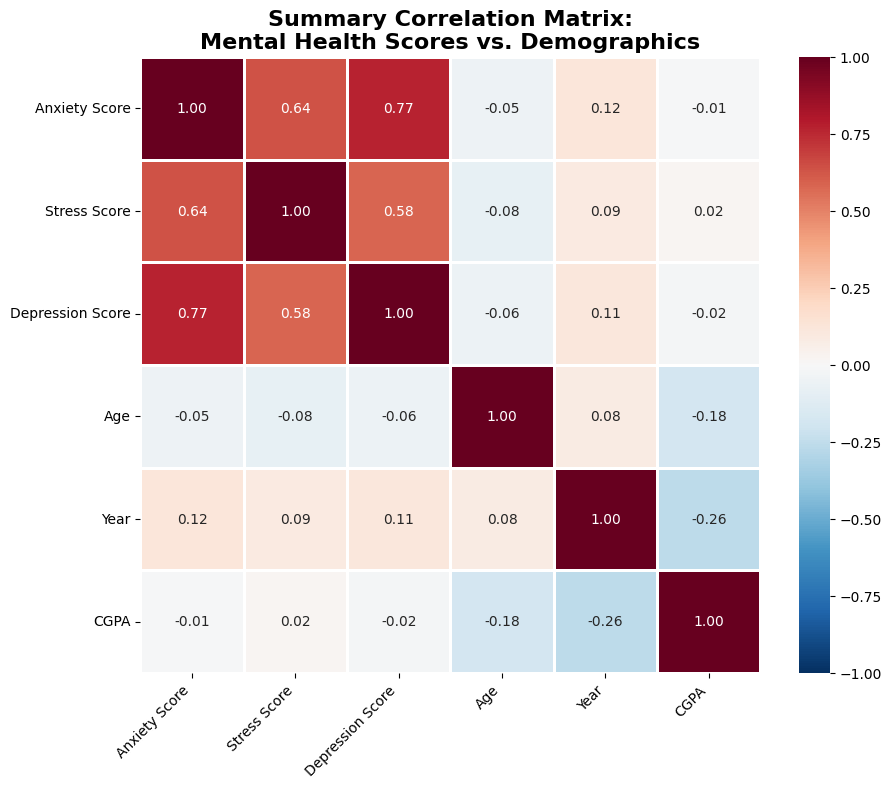

In [ ]:
#8
import seaborn as sns
import matplotlib.pyplot as plt

print("\n--- Generating Condensed Summary Heatmap ---")

# 1. Select the High-Level Features (Scores + Demographics)
# We ignore the individual questions and focus on the Totals
summary_features = [
    'Anxiety Score',
    'Stress Score',
    'Depression Score',
    'Age',
    'Year',
    'CGPA'
]

# 2. Prepare the Data
# We create a copy so we don't mess up the original dataframe
df_summary = df_renamed[summary_features].copy()

# 3. Encode Categorical Data for Correlation
# (Correlation only works on numbers, so we convert "First Year", "Male" etc. to 0, 1, 2...)
for col in ['Age', 'Year', 'CGPA']:
    if df_summary[col].dtype == 'object':
        df_summary[col] = df_summary[col].astype('category').cat.codes

# 4. Plot the Heatmap
plt.figure(figsize=(10, 8))
heatmap = sns.heatmap(df_summary.corr(),
                      annot=True,       # Show the numbers
                      cmap='RdBu_r',    # Red=Positive, Blue=Negative
                      vmin=-1, vmax=1,  # Fix scale from -1 to 1
                      fmt='.2f',        # 2 decimal places
                      linewidths=1,
                      linecolor='white')

plt.title('Summary Correlation Matrix:\nMental Health Scores vs. Demographics', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()

/tmp/ipython-input-3858481513.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Depression Label', data=df,


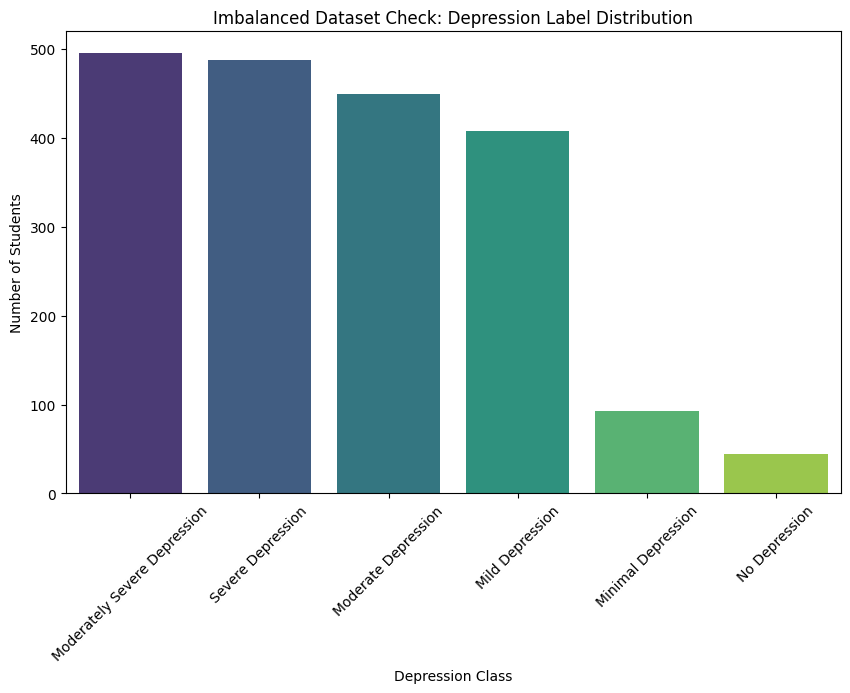


Exact Class Counts:
Depression Label
Moderately Severe Depression    495
Severe Depression               488
Moderate Depression             449
Mild Depression                 408
Minimal Depression               93
No Depression                    44
Name: count, dtype: int64


In [ ]:
#9
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Visualize the Target Variable Distribution
plt.figure(figsize=(10, 6))
# We use the cleaned dataframe 'df' from the previous step
# Order by count to see which class is dominant
sns.countplot(x='Depression Label', data=df,
              order=df['Depression Label'].value_counts().index,
              palette='viridis')

plt.title("Imbalanced Dataset Check: Depression Label Distribution")
plt.xlabel("Depression Class")
plt.ylabel("Number of Students")
plt.xticks(rotation=45)
plt.show()

# 2. Print exact numbers
print("\nExact Class Counts:")
print(df['Depression Label'].value_counts())

*From* inside the bar chart, we have seen that, the parameters are extremely biased and imbalanced! Most of the weight in terms of frequencies are leaned towards the "Moderately Severe Depression" feature, and then comes "Severe Depression" and then "Moderate Depression" and then comes "Mild Depression" and later on you will see "Minimal Depression" followed by "No depression" with a lower frequency value of 44!

The problem with this is: The dataset is first of all right skewed, and that makes the possibility to predict "No depression" highly unlikely. If we don't fix this, the model will be biased. It will learn to predict "Severe Depression" all the time because it sees it so often, and it will likely fail to recognize "No Depression" cases because it rarely sees them.

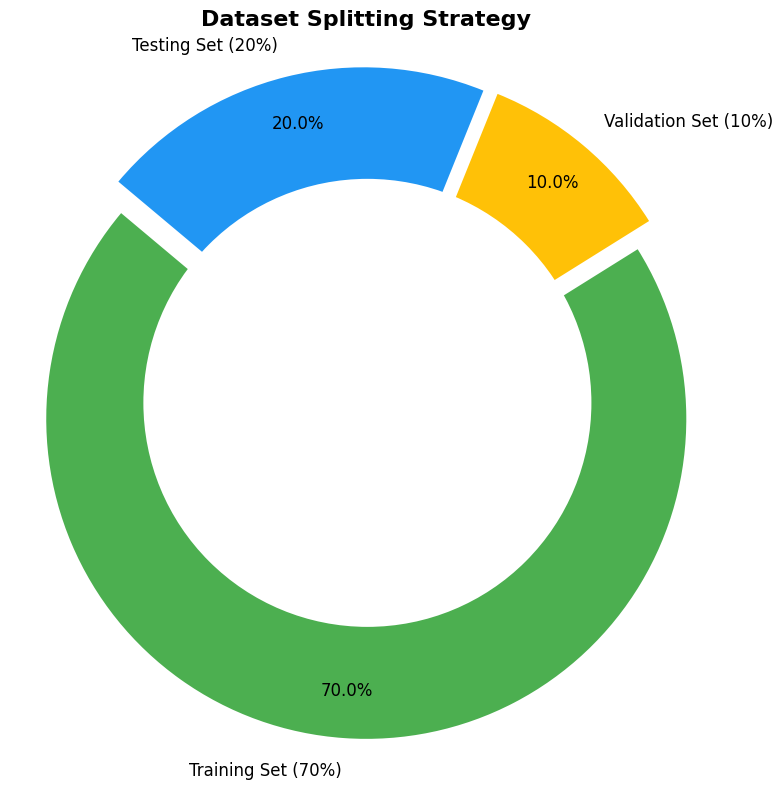

In [ ]:
#10
# Data Split Proportions
sizes = [70, 10, 20]
labels = ['Training Set (70%)', 'Validation Set (10%)', 'Testing Set (20%)']
colors = ['#4CAF50', '#FFC107', '#2196F3']  # Green, Amber, Blue
explode = (0.05, 0.05, 0.05)  # slight explosion for all slices to separate them

# Create Pie Chart
plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140, pctdistance=0.85, explode=explode, textprops={'fontsize': 12})

# Draw a circle at the center to make it look like a Donut Chart
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Dataset Splitting Strategy', fontsize=16, fontweight='bold')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()

There are 29 numerical features: 

['Anx: Nervous', 'Anx: Worrying', 'Anx: Relaxing', 'Anx: Annoyed', 'Anx: Obsessive Worry', 'Anx: Restless', 'Anx: Afraid', 'Anxiety Score', 'Str: Upset', 'Str: No Control', 'Str: Stressed', 'Str: Cannot Cope', 'Str: Confident', 'Str: Things Going Well', 'Str: Control Irritation', 'Str: Top Performance', 'Str: Angered', 'Str: Piling Up', 'Stress Score', 'Dep: No Interest', 'Dep: Feeling Down', 'Dep: Sleep Issues', 'Dep: Tired/Low Energy', 'Dep: Appetite Change', 'Dep: Self-Blame', 'Dep: Concentration', 'Dep: Slow/Restless', 'Dep: Suicidal Thoughts', 'Depression Score']
There are 8 numerical features: 

['Age', 'Gender', 'Year', 'CGPA', 'Scholarship', 'Anxiety Label', 'Stress Label', 'Depression Label']
       DESCRIPTIVE STATISTICS REPORT      

--- 1. Numerical Statistics (Mean, Median, Std Dev) ---


,count,mean,std,min,25%,50%,75%,max
Anx: Nervous,1977.0,1.770359,0.951704,0.0,1.0,2.0,3.0,3.0
Anx: Worrying,1977.0,1.629236,1.028252,0.0,1.0,2.0,3.0,3.0
Anx: Relaxing,1977.0,1.747092,0.996336,0.0,1.0,2.0,3.0,3.0
Anx: Annoyed,1977.0,1.777441,0.966041,0.0,1.0,2.0,3.0,3.0
Anx: Obsessive Worry,1977.0,1.859383,0.982362,0.0,1.0,2.0,3.0,3.0
Anx: Restless,1977.0,1.787557,0.993087,0.0,1.0,2.0,3.0,3.0
Anx: Afraid,1977.0,1.719777,1.057735,0.0,1.0,2.0,3.0,3.0
Anxiety Score,1977.0,12.290845,5.496399,0.0,8.0,13.0,17.0,21.0
Str: Upset,1977.0,2.341932,1.178599,0.0,2.0,2.0,3.0,4.0
Str: No Control,1977.0,2.319676,1.154547,0.0,2.0,2.0,3.0,4.0



--- 2. Categorical Statistics (Count, Frequency, Top Class) ---


,count,unique,top,freq
Age,1977,5,18-22,1273
Gender,1971,3,Male,1369
Year,1977,5,First Year or Equivalent,592
CGPA,1977,6,3.00 - 3.39,572
Scholarship,1977,2,No,1571
Anxiety Label,1977,4,Severe Anxiety,714
Stress Label,1977,3,Moderate Stress,1316
Depression Label,1977,6,Moderately Severe Depression,495



--- Unique Values in Numerical Features ---


...


--- Variance of Numerical Features ---


,0
Anx: Nervous,0.905740
Anx: Worrying,1.057303
Anx: Relaxing,0.992685
Anx: Annoyed,0.933236
Anx: Obsessive Worry,0.965035
Anx: Restless,0.986222
Anx: Afraid,1.118804
Anxiety Score,30.210407
Str: Upset,1.389096
Str: No Control,1.332978



--- Skewness of Numerical Features ---


,0
Anx: Nervous,-0.212193
Anx: Worrying,-0.039330
Anx: Relaxing,-0.159674
Anx: Annoyed,-0.163491
Anx: Obsessive Worry,-0.299283
Anx: Restless,-0.213637
Anx: Afraid,-0.154958
Anxiety Score,-0.205279
Str: Upset,-0.239091
Str: No Control,-0.172693



--- 3. Distribution of Survey Answers (Histograms) ---


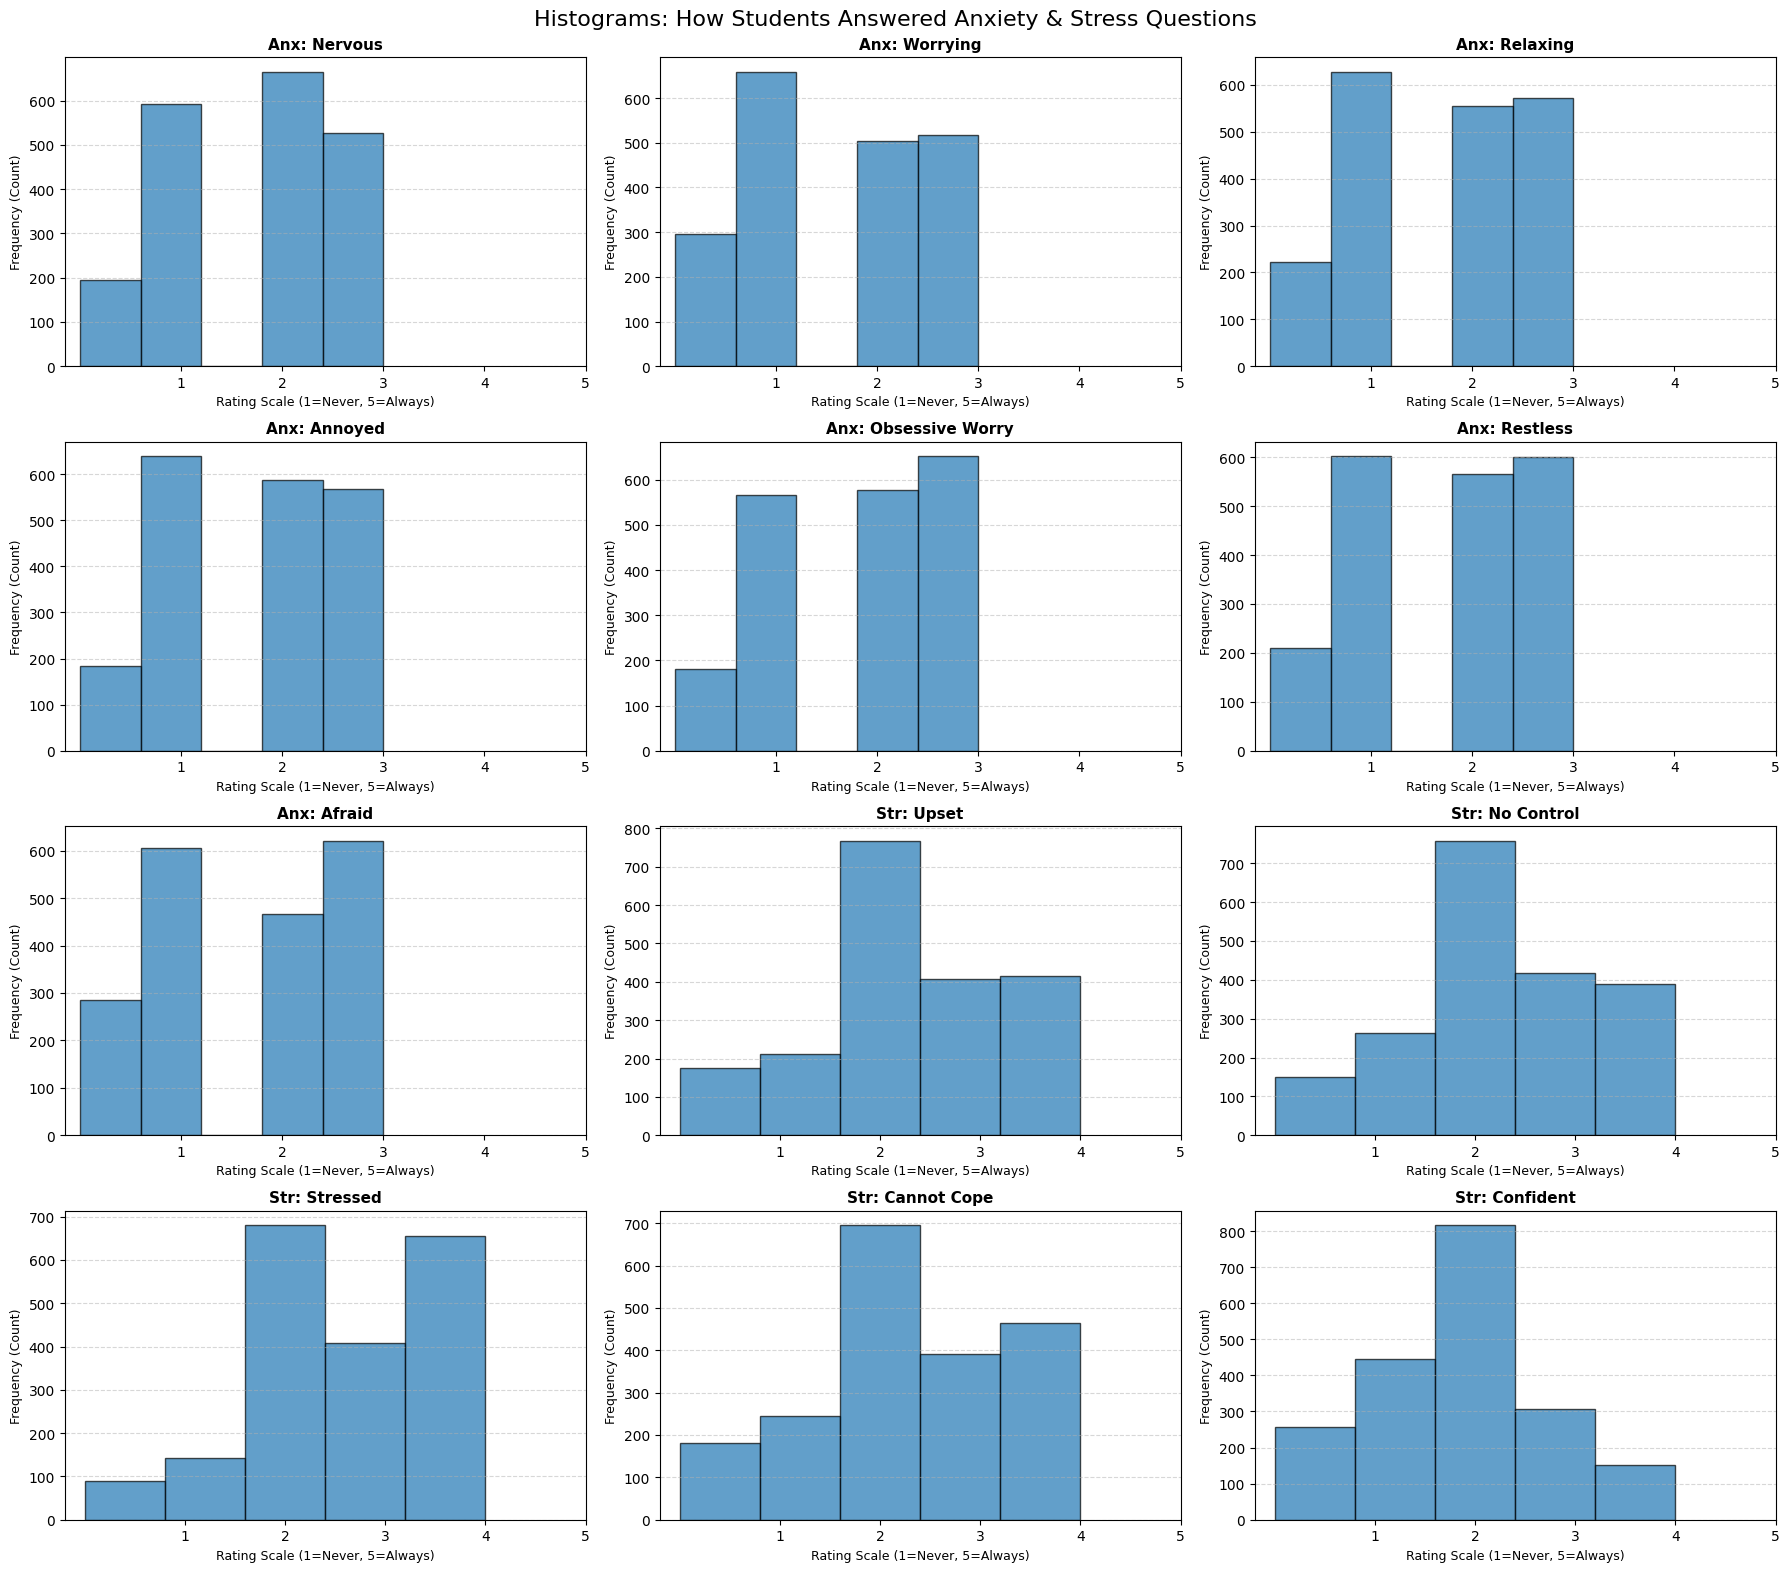


--- 4. Density Distribution of Total Scores ---


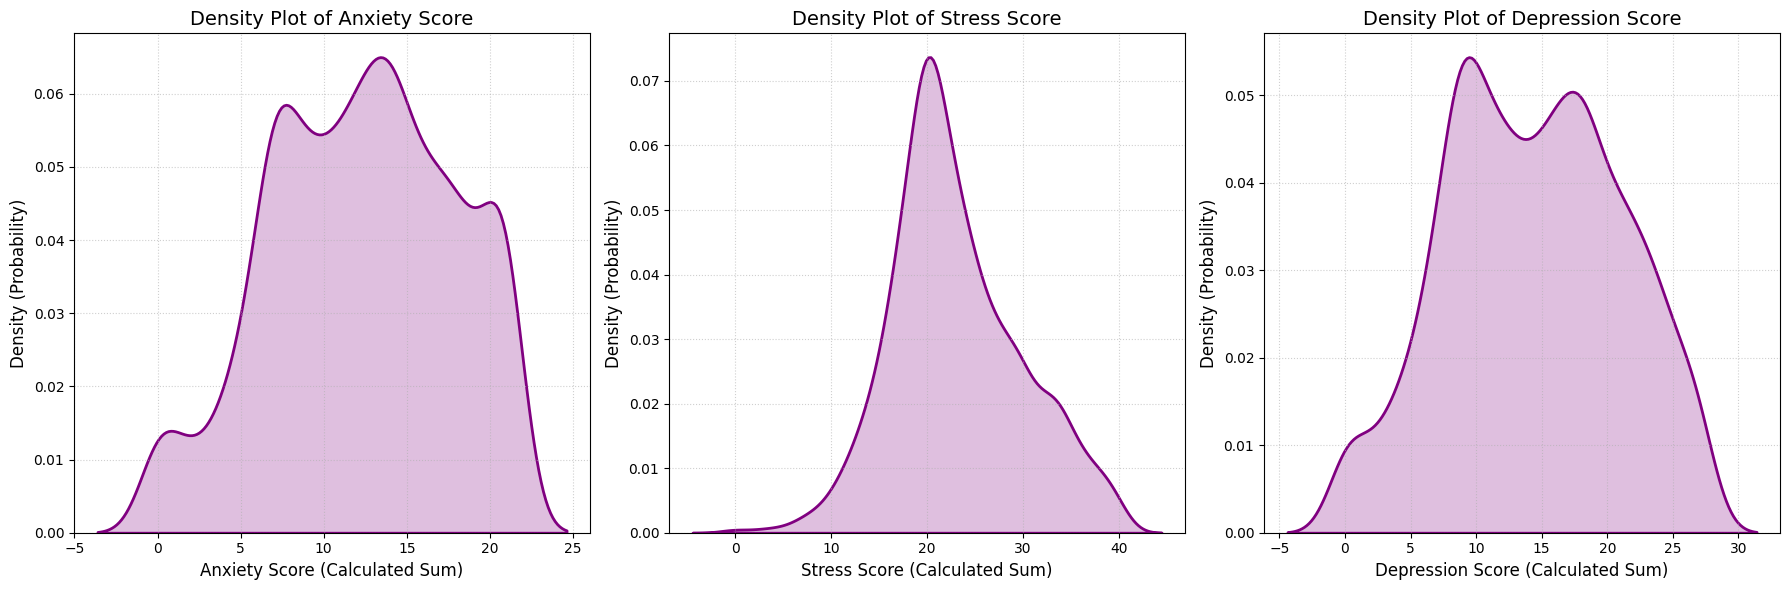


--- 5. Outlier Detection (Boxplots) ---


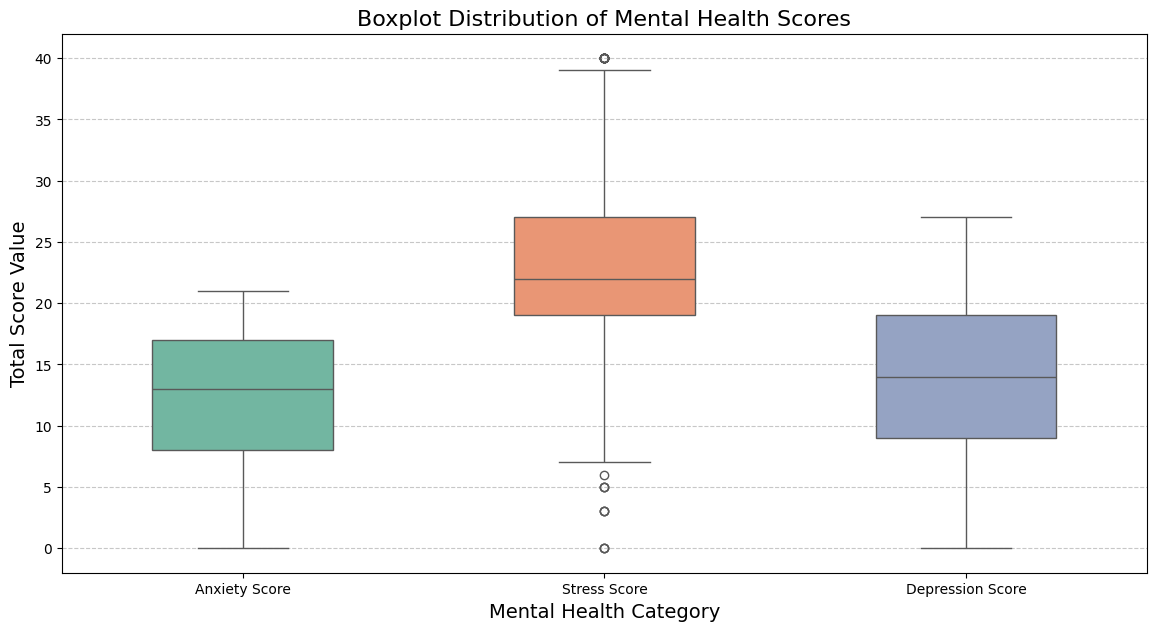

,Anx: Nervous,Anx: Worrying,Anx: Relaxing,Anx: Annoyed,Anx: Obsessive Worry,Anx: Restless,Anx: Afraid,Anxiety Score,Str: Upset,Str: No Control,...,Dep: No Interest,Dep: Feeling Down,Dep: Sleep Issues,Dep: Tired/Low Energy,Dep: Appetite Change,Dep: Self-Blame,Dep: Concentration,Dep: Slow/Restless,Dep: Suicidal Thoughts,Depression Score
Anx: Nervous,1.000000,0.495772,0.511390,0.635193,0.643153,0.580194,0.598137,0.805124,0.491888,0.511299,...,0.178723,0.592705,0.440335,0.500472,0.415241,0.555560,0.483629,0.428253,0.416095,0.627624
Anx: Worrying,0.495772,1.000000,0.473536,0.481888,0.498965,0.441217,0.447900,0.698547,0.342687,0.356513,...,0.187395,0.426127,0.363543,0.393809,0.361505,0.417127,0.388554,0.324906,0.289480,0.492171
Anx: Relaxing,0.511390,0.473536,1.000000,0.564550,0.517929,0.519029,0.499364,0.740075,0.377510,0.400276,...,0.205356,0.494548,0.438430,0.474976,0.372413,0.444108,0.436933,0.371762,0.318506,0.554905
Anx: Annoyed,0.635193,0.481888,0.564550,1.000000,0.695984,0.583702,0.605070,0.824525,0.459347,0.492151,...,0.204851,0.588961,0.443092,0.508928,0.423595,0.563925,0.503970,0.447433,0.422247,0.642284
Anx: Obsessive Worry,0.643153,0.498965,0.517929,0.695984,1.000000,0.660851,0.662909,0.846620,0.435808,0.459529,...,0.190281,0.616251,0.452073,0.515111,0.425131,0.576295,0.513104,0.434942,0.389694,0.642935
Anx: Restless,0.580194,0.441217,0.519029,0.583702,0.660851,1.000000,0.620680,0.797915,0.396751,0.422960,...,0.189561,0.559738,0.442977,0.533634,0.412510,0.500339,0.451295,0.438958,0.387305,0.611745
Anx: Afraid,0.598137,0.447900,0.499364,0.605070,0.662909,0.620680,1.000000,0.807292,0.452806,0.459616,...,0.209400,0.625255,0.482671,0.509573,0.431500,0.583713,0.493026,0.476058,0.446520,0.666259
Anxiety Score,0.805124,0.698547,0.740075,0.824525,0.846620,0.797915,0.807292,1.000000,0.535160,0.561286,...,0.247788,0.707107,0.555328,0.622422,0.515040,0.659581,0.592335,0.529625,0.483708,0.767879
Str: Upset,0.491888,0.342687,0.377510,0.459347,0.435808,0.396751,0.452806,0.535160,1.000000,0.672744,...,0.131622,0.461601,0.364514,0.397025,0.323675,0.451946,0.376988,0.338766,0.327872,0.496871
Str: No Control,0.511299,0.356513,0.400276,0.492151,0.459529,0.422960,0.459616,0.561286,0.672744,1.000000,...,0.128084,0.471070,0.386529,0.414361,0.322515,0.470099,0.403984,0.341878,0.320479,0.510018


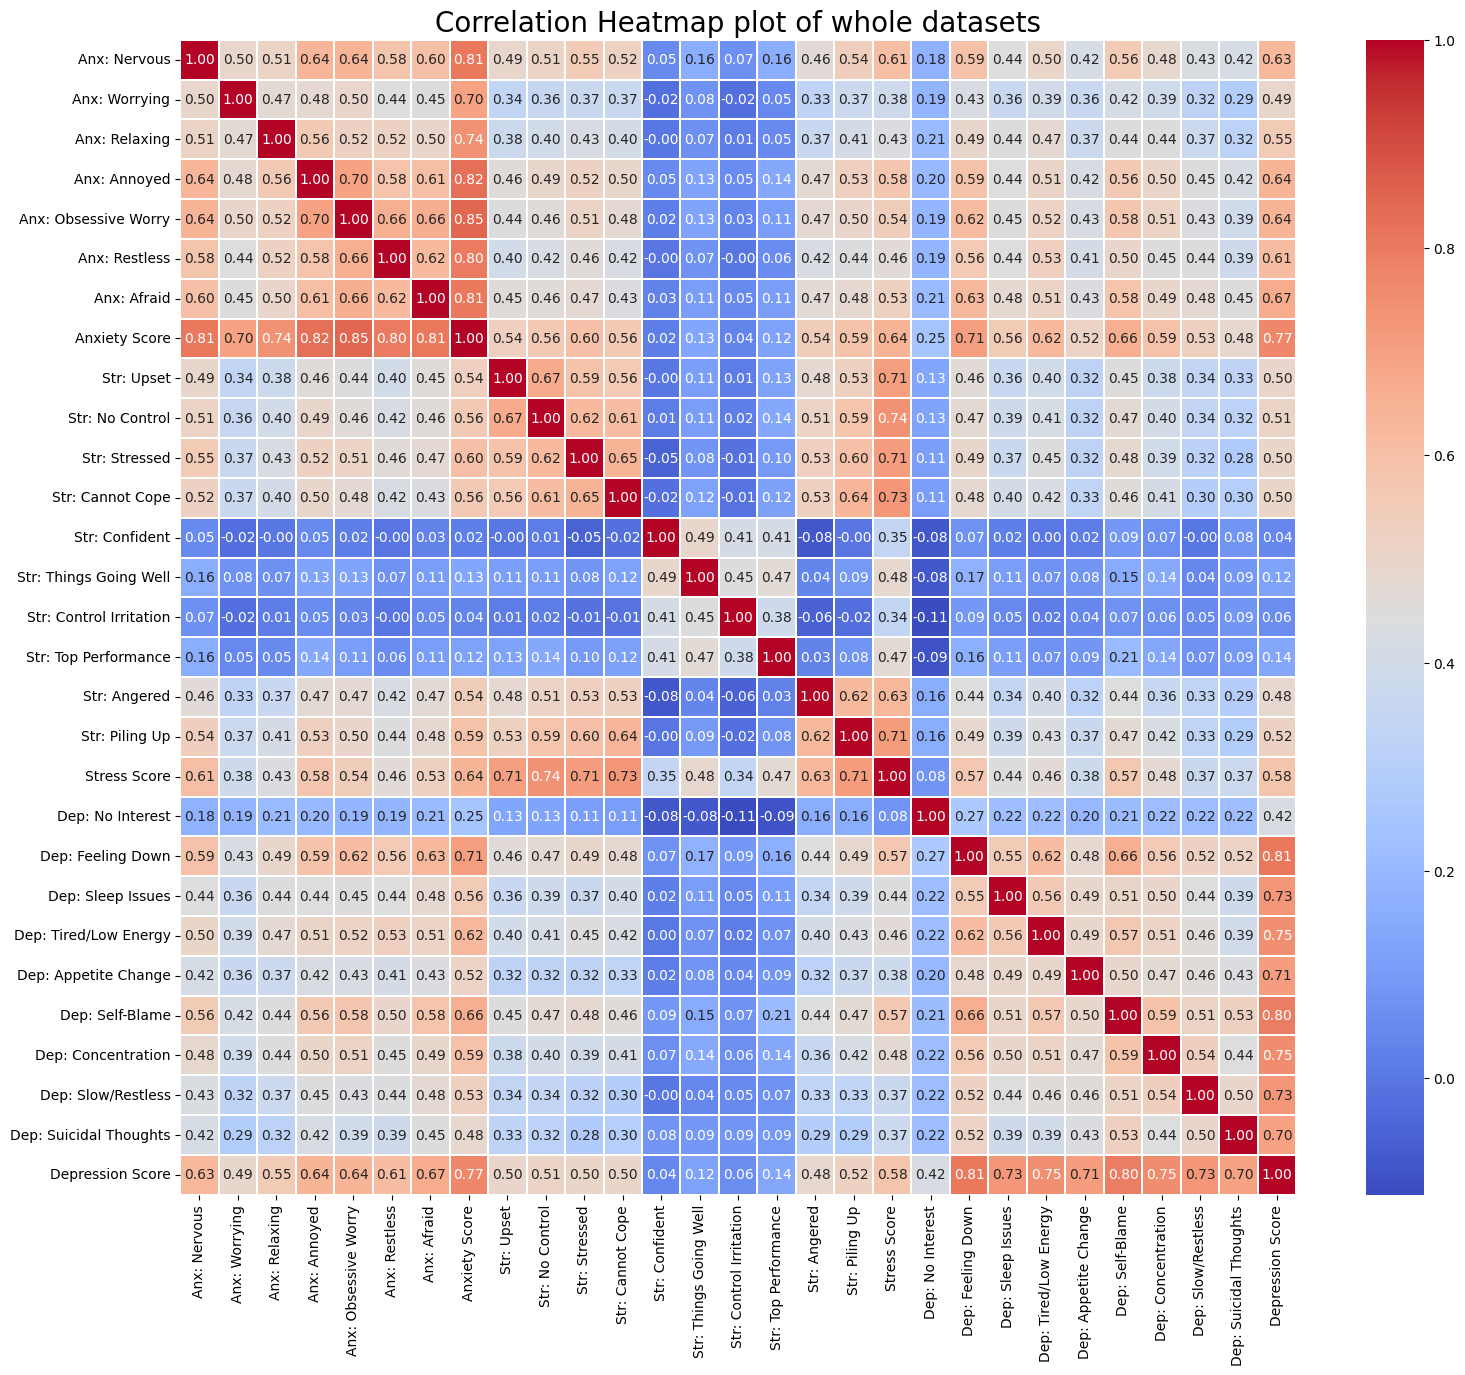


--- 6. Correlation Analysis (Target: Depression Score) ---


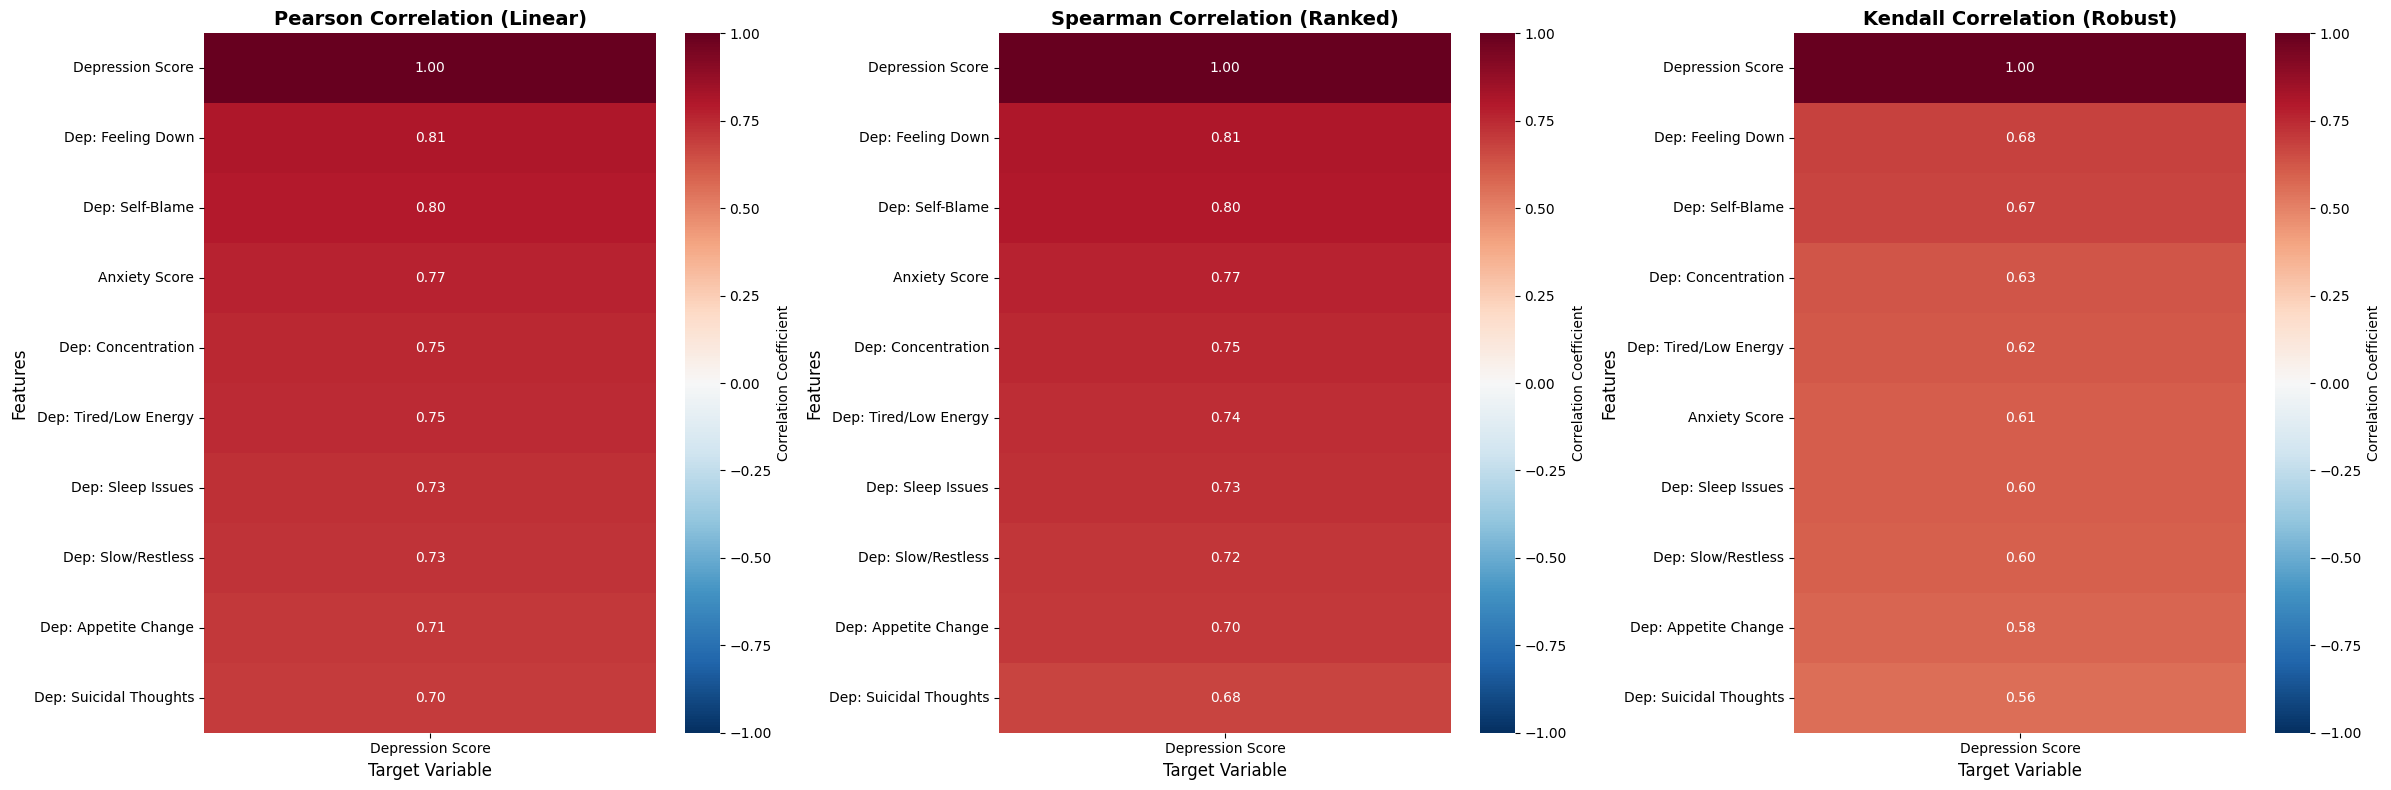

In [ ]:
#11
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# ==========================================
# 1. RENAME FEATURES (For Short, Clean Labels)
# ==========================================
column_mapping = {
    '1. Age': 'Age',
    '2. Gender': 'Gender',
    '5. Academic Year': 'Year',
    '6. Current CGPA': 'CGPA',
    '7. Did you receive a waiver or scholarship at your university?': 'Scholarship',
    # Anxiety
    '1. In a semester, how often you felt nervous, anxious or on edge due to academic pressure? ': 'Anx: Nervous',
    '2. In a semester, how often have you been unable to stop worrying about your academic affairs? ': 'Anx: Worrying',
    '3. In a semester, how often have you had trouble relaxing due to academic pressure? ': 'Anx: Relaxing',
    '4. In a semester, how often have you been easily annoyed or irritated because of academic pressure?': 'Anx: Annoyed',
    '5. In a semester, how often have you worried too much about academic affairs? ': 'Anx: Obsessive Worry',
    '6. In a semester, how often have you been so restless due to academic pressure that it is hard to sit still?': 'Anx: Restless',
    '7. In a semester, how often have you felt afraid, as if something awful might happen?': 'Anx: Afraid',
    'Anxiety Value': 'Anxiety Score',
    'Anxiety Label': 'Anxiety Label',
    # Stress
    '1. In a semester, how often have you felt upset due to something that happened in your academic affairs? ': 'Str: Upset',
    '2. In a semester, how often you felt as if you were unable to control important things in your academic affairs?': 'Str: No Control',
    '3. In a semester, how often you felt nervous and stressed because of academic pressure? ': 'Str: Stressed',
    '4. In a semester, how often you felt as if you could not cope with all the mandatory academic activities? (e.g, assignments, quiz, exams) ': 'Str: Cannot Cope',
    '5. In a semester, how often you felt confident about your ability to handle your academic / university problems?': 'Str: Confident',
    '6. In a semester, how often you felt as if things in your academic life is going on your way? ': 'Str: Things Going Well',
    '7. In a semester, how often are you able to control irritations in your academic / university affairs? ': 'Str: Control Irritation',
    '8. In a semester, how often you felt as if your academic performance was on top?': 'Str: Top Performance',
    '9. In a semester, how often you got angered due to bad performance or low grades that is beyond your control? ': 'Str: Angered',
    '10. In a semester, how often you felt as if academic difficulties are piling up so high that you could not overcome them? ': 'Str: Piling Up',
    'Stress Value': 'Stress Score',
    'Stress Label': 'Stress Label',
    # Depression
    '1. In a semester, how often have you had little interest or pleasure in doing things?': 'Dep: No Interest',
    '2. In a semester, how often have you been feeling down, depressed or hopeless?': 'Dep: Feeling Down',
    '3. In a semester, how often have you had trouble falling or staying asleep, or sleeping too much? ': 'Dep: Sleep Issues',
    '4. In a semester, how often have you been feeling tired or having little energy? ': 'Dep: Tired/Low Energy',
    '5. In a semester, how often have you had poor appetite or overeating? ': 'Dep: Appetite Change',
    '6. In a semester, how often have you been feeling bad about yourself - or that you are a failure or have let yourself or your family down? ': 'Dep: Self-Blame',
    '7. In a semester, how often have you been having trouble concentrating on things, such as reading the books or watching television? ': 'Dep: Concentration',
    "8. In a semester, how often have you moved or spoke too slowly for other people to notice? Or you've been moving a lot more than usual because you've been restless? ": 'Dep: Slow/Restless',
    '9. In a semester, how often have you had thoughts that you would be better off dead, or of hurting yourself? ': 'Dep: Suicidal Thoughts',
    'Depression Value': 'Depression Score',
    'Depression Label': 'Depression Label'
}

df_renamed = df.rename(columns=column_mapping)
numerical_cols = df_renamed.select_dtypes(include=['int64', 'float64']).columns
numerical_features=numerical_cols.tolist()
print(f'There are {len(numerical_features)} numerical features:', '\n')
print(numerical_features)

categorical_cols = df_renamed.select_dtypes(include=['object']).columns
categorical_features=categorical_cols.tolist()
print(f'There are {len(categorical_features)} numerical features:', '\n')
print(categorical_features)

# ==========================================
# 2. DESCRIPTIVE STATISTICS (MISSING PART ADDED)
# ==========================================
print("==========================================")
print("       DESCRIPTIVE STATISTICS REPORT      ")
print("==========================================\n")

print("--- 1. Numerical Statistics (Mean, Median, Std Dev) ---")
# Transpose (.T) makes it easier to read
display(df_renamed[numerical_cols].describe().T)
print("\n--- 2. Categorical Statistics (Count, Frequency, Top Class) ---")
display(df_renamed[categorical_cols].describe().T)

#Number Unique values in each feature
print("\n--- Unique Values in Numerical Features ---")
display(df_renamed[numerical_cols].nunique())

#Missing Values
print("\n--- Missing Values in Numerical Features ---")
display(df_renamed[numerical_cols].isnull().sum())

#No of unique values in each categorical feature
print("\n--- Unique Values in Categorical Features ---")
unique_counts=df_renamed[categorical_cols].nunique()
display(unique_counts)

#variance of each numerical features
print("\n--- Variance of Numerical Features ---")
display(df_renamed[numerical_cols].var())

#Skew in numerical features
print("\n--- Skewness of Numerical Features ---")
display(df_renamed[numerical_cols].skew())


# ==========================================
# 3. IMPROVED HISTOGRAMS (Loop for labels)
# ==========================================
print("\n--- 3. Distribution of Survey Answers (Histograms) ---")
# Select first 12 numerical columns (excluding totals if present)
cols_to_plot = [c for c in numerical_cols if "Score" not in c][:12]

fig, axes = plt.subplots(4, 3, figsize=(18, 16))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    axes[i].hist(df_renamed[col], bins=5, color='#1f77b4', edgecolor='black', alpha=0.7)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel("Rating Scale (1=Never, 5=Always)", fontsize=9)
    axes[i].set_ylabel("Frequency (Count)", fontsize=9)
    axes[i].set_xticks([1, 2, 3, 4, 5]) # Force integer ticks
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.suptitle("Histograms: How Students Answered Anxiety & Stress Questions", fontsize=16)
plt.show()

# ==========================================
# 4. IMPROVED DENSITY PLOTS
# ==========================================
print("\n--- 4. Density Distribution of Total Scores ---")
score_features = ['Anxiety Score', 'Stress Score', 'Depression Score']
existing_scores = [c for c in score_features if c in df_renamed.columns]

if existing_scores:
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    for i, col in enumerate(existing_scores):
        sns.kdeplot(df_renamed[col], ax=axes[i], fill=True, color='purple', linewidth=2)
        axes[i].set_title(f'Density Plot of {col}', fontsize=14)
        axes[i].set_xlabel(f'{col} (Calculated Sum)', fontsize=12)
        axes[i].set_ylabel('Density (Probability)', fontsize=12)
        axes[i].grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout()
    plt.show()

# ==========================================
# 5. IMPROVED BOXPLOTS
# ==========================================
print("\n--- 5. Outlier Detection (Boxplots) ---")
if existing_scores:
    plt.figure(figsize=(14, 7))
    sns.boxplot(data=df_renamed[existing_scores], palette="Set2", width=0.5)

    plt.title("Boxplot Distribution of Mental Health Scores", fontsize=16)
    plt.ylabel("Total Score Value", fontsize=14)
    plt.xlabel("Mental Health Category", fontsize=14)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

# ==========================================
# 6. IMPROVED CORRELATION HEATMAPS
# ==========================================
# Calculate the correlation matrix
correlation_matrix = df_renamed[numerical_cols].corr()
display(correlation_matrix)

# Plotting the heatmap for correlation matrix
plt.figure(figsize=(18, 15))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.3)
plt.title('Correlation Heatmap plot of whole datasets', fontsize=20)
plt.show()

print("\n--- 6. Correlation Analysis (Target: Depression Score) ---")
target_var = 'Depression Score'

if target_var in df_renamed.columns:
    fig, ax = plt.subplots(1, 3, figsize=(24, 8))

    # Calculate correlations
    corr_pearson = df_renamed[numerical_cols].corr(method='pearson')[[target_var]].sort_values(by=target_var, ascending=False).head(10)
    corr_spearman = df_renamed[numerical_cols].corr(method='spearman')[[target_var]].sort_values(by=target_var, ascending=False).head(10)
    corr_kendall = df_renamed[numerical_cols].corr(method='kendall')[[target_var]].sort_values(by=target_var, ascending=False).head(10)

    # Helper function for consistent heatmap styling
    def plot_heatmap_custom(data, axis, title):
        sns.heatmap(data, ax=axis, annot=True, cmap='RdBu_r', vmin=-1, vmax=1,
                    fmt='.2f', cbar_kws={'label': 'Correlation Coefficient'})
        axis.set_title(title, fontsize=14, fontweight='bold')
        axis.set_ylabel('Features', fontsize=12)
        axis.set_xlabel('Target Variable', fontsize=12)

    plot_heatmap_custom(corr_pearson, ax[0], 'Pearson Correlation (Linear)')
    plot_heatmap_custom(corr_spearman, ax[1], 'Spearman Correlation (Ranked)')
    plot_heatmap_custom(corr_kendall, ax[2], 'Kendall Correlation (Robust)')

    plt.tight_layout()
    plt.show()
else:
    print(f"Target '{target_var}' not found. Skipping correlation plots.")

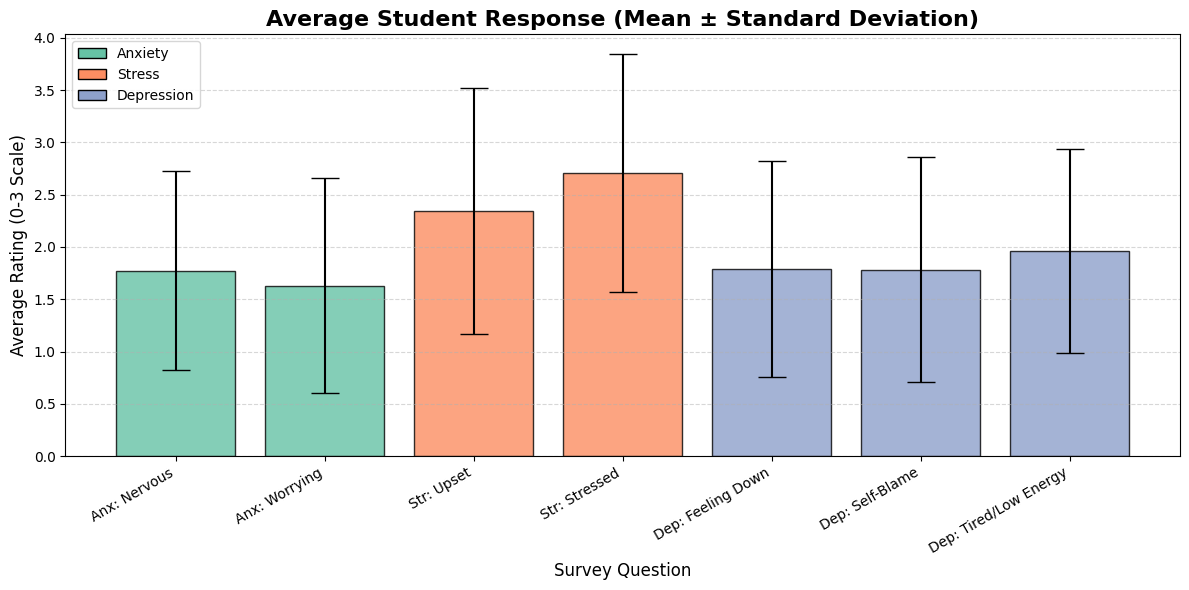

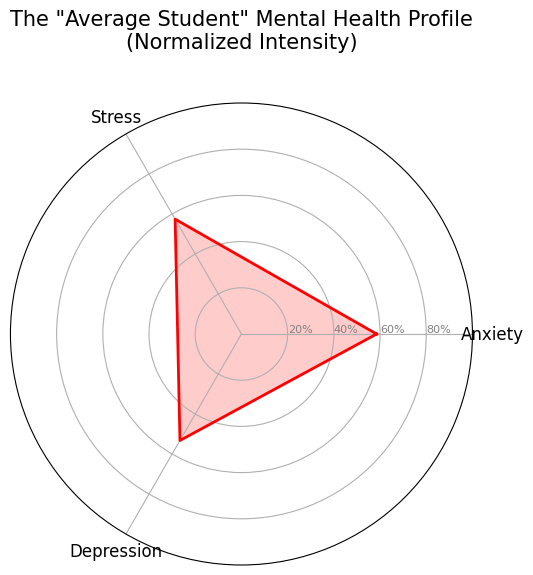

In [ ]:
#12
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ==========================================
# 1. PREPARE DATA
# ==========================================
# We focus on the "Questions" (not the total scores) to see which symptoms are most common.
# We pick a few representative questions from each category for a clean plot.
selected_features = [
    'Anx: Nervous', 'Anx: Worrying',
    'Str: Upset', 'Str: Stressed',
    'Dep: Feeling Down', 'Dep: Self-Blame', 'Dep: Tired/Low Energy'
]

# Calculate Mean and Std Dev
means = df_renamed[selected_features].mean()
std_devs = df_renamed[selected_features].std()

# ==========================================
# 2. PLOT 1: BAR CHART WITH ERROR BARS
# ==========================================
plt.figure(figsize=(12, 6))

# Create bars
bars = plt.bar(selected_features, means, yerr=std_devs, capsize=10,
               color=['#66c2a5', '#66c2a5', '#fc8d62', '#fc8d62', '#8da0cb', '#8da0cb', '#8da0cb'],
               edgecolor='black', alpha=0.8)

plt.title('Average Student Response (Mean ± Standard Deviation)', fontsize=16, fontweight='bold')
plt.ylabel('Average Rating (0-3 Scale)', fontsize=12)
plt.xlabel('Survey Question', fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Add Legend manually to explain colors
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#66c2a5', edgecolor='black', label='Anxiety'),
                   Patch(facecolor='#fc8d62', edgecolor='black', label='Stress'),
                   Patch(facecolor='#8da0cb', edgecolor='black', label='Depression')]
plt.legend(handles=legend_elements, loc='upper left')

plt.tight_layout()
plt.show()

# ==========================================
# 3. PLOT 2: RADAR CHART (The "Average Student" Profile)
# ==========================================
# We compare the normalized totals of the three categories
categories = ['Anxiety Score', 'Stress Score', 'Depression Score']
# Normalize scores to 0-1 scale so they can be compared on one chart
# (Because Stress score goes to 40, but Anxiety only to 21)
normalized_means = []
for cat in categories:
    max_val = df_renamed[cat].max()
    mean_val = df_renamed[cat].mean()
    normalized_means.append(mean_val / max_val)

# Radar Chart Setup
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1] # Close the loop
normalized_means += normalized_means[:1] # Close the loop

plt.figure(figsize=(6, 6))
ax = plt.subplot(111, polar=True)

# Draw one axe per variable + labels
plt.xticks(angles[:-1], ['Anxiety', 'Stress', 'Depression'], color='black', size=12)

# Draw ylabels
ax.set_rlabel_position(0)
plt.yticks([0.2, 0.4, 0.6, 0.8], ["20%", "40%", "60%", "80%"], color="grey", size=8)
plt.ylim(0, 1)

# Plot data
ax.plot(angles, normalized_means, linewidth=2, linestyle='solid', color='red')
ax.fill(angles, normalized_means, 'red', alpha=0.2)

plt.title('The "Average Student" Mental Health Profile\n(Normalized Intensity)', size=15, y=1.1)
plt.show()

In [ ]:
#13
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 1. Feature Selection & Encoding (Same as before)
cols_to_drop = ['Depression Label', 'Depression Value',
                'Anxiety Label', 'Anxiety Value',
                'Stress Label', 'Stress Value']
X = df.drop(columns=cols_to_drop, errors='ignore')
y = df['Depression Label']

le_X = LabelEncoder()
le_y = LabelEncoder()
for col in X.columns:
    if X[col].dtype == 'object':
        X[col] = le_X.fit_transform(X[col].astype(str))
y = le_y.fit_transform(y)
class_names = le_y.classes_
# 2. Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. SPLITTING WITH VALIDATION SET
# Goal: 70% Train, 10% Validation, 20% Test

# Step A: Split off the 20% Test Set
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# Step B: Split the remaining 80% into Train (70% total) and Validation (10% total)
# 10% of total is 12.5% of the remaining 80% (10/80 = 0.125)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.125, random_state=42, stratify=y_train_val
)

print(">> Split Complete:")
print(f"Training Set:   {X_train.shape[0]} rows (70%)")
print(f"Validation Set: {X_val.shape[0]} rows (10%)")
print(f"Test Set:       {X_test.shape[0]} rows (20%)")



>> Split Complete:
Training Set:   1383 rows (70%)
Validation Set: 198 rows (10%)
Test Set:       396 rows (20%)


--- 1. OPTIMIZING KNN (ELBOW METHOD) ---
>> Best K detected: 25 (Error Rate: 0.3232)


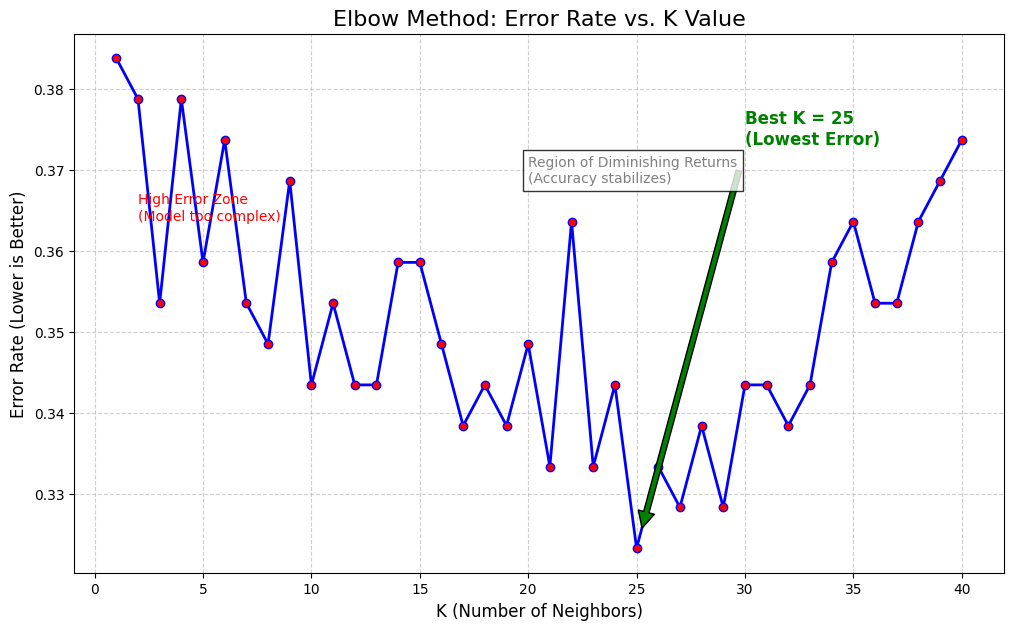


--- 2. TRAINING FINAL SUPERVISED MODELS ---
Training KNN with K=25...
Training Decision Tree...
Training Logistic Regression...
Training Neural Network...

--- 3. UNSUPERVISED LEARNING (K-MEANS) ---


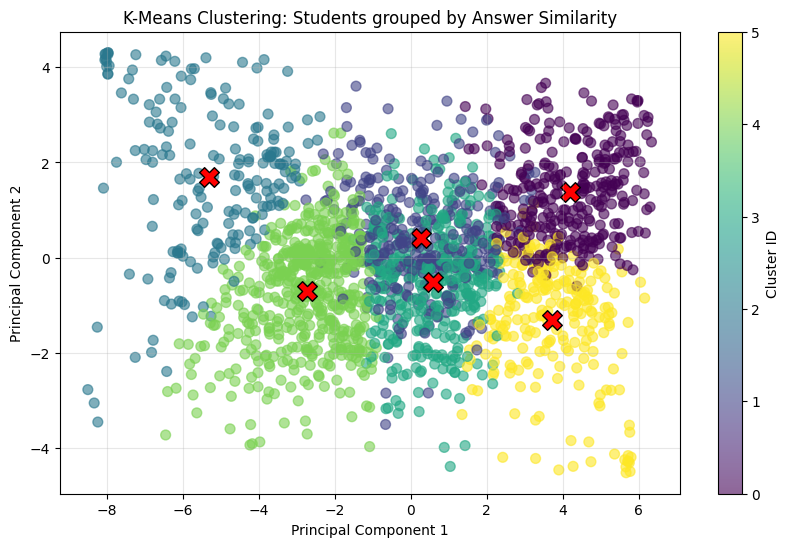


>> Models Trained. Visualizations Complete.
Cluster Centers (mean values of features for each cluster):
[[-0.10142289 -0.26616997  0.11669607  0.16165336 -0.12938525  0.95344232
   0.63000163  0.72480227  0.9656866   0.92922485  0.81108783  0.92726069
   1.00356163  1.05503843  0.9965979   1.05679484  0.76472164  0.99058431
   0.78747089  0.86948663  0.95058159  1.09662     0.08987013  0.94597163
   0.76951086  0.8140142   0.75272999  0.94329854  0.89786876  0.64154333
   0.7577854 ]
 [ 0.22675398 -0.01790863  0.05539988 -0.29147325 -0.02077395  0.03433782
   0.14253159  0.02877873  0.07669789  0.19254596  0.21092391  0.26212833
  -0.34934127 -0.42397338 -0.518065   -0.46834232  0.20877816  0.09800037
   0.08186642  0.10708352 -0.38482404 -0.48367215  0.29402211  0.44294033
   0.28681659  0.21341179  0.3619734   0.35827789  0.28602391  0.40543908
   0.40410529]
 [ 0.05737695  0.2282643  -0.20129754 -0.05451113 -0.01586466 -1.33241233
  -1.03991725 -1.17052369 -1.29828572 -1.30151082 -

In [ ]:
#14
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score

# ======================================================
# A. KNN HYPERPARAMETER TUNING (THE ELBOW METHOD)
# ======================================================
print("--- 1. OPTIMIZING KNN (ELBOW METHOD) ---")

error_rate = []
k_range = range(1, 41) # Check K from 1 to 40

for i in k_range:
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)
    pred_i = knn.predict(X_val)
    error_rate.append(np.mean(pred_i != y_val))


# Detect the Best K
min_error = min(error_rate)
best_k = k_range[error_rate.index(min_error)]
print(f">> Best K detected: {best_k} (Error Rate: {min_error:.4f})")

# --- PLOTTING WITH INFERENCES ---
plt.figure(figsize=(12, 7))
plt.plot(k_range, error_rate, color='blue', linestyle='-', marker='o',
         markerfacecolor='red', markersize=6, linewidth=2)

plt.title('Elbow Method: Error Rate vs. K Value', fontsize=16)
plt.xlabel('K (Number of Neighbors)', fontsize=12)
plt.ylabel('Error Rate (Lower is Better)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Annotation 1: Point to Best K
plt.annotate(f'Best K = {best_k}\n(Lowest Error)',
             xy=(best_k, min_error),
             xytext=(best_k + 5, min_error + 0.05),
             arrowprops=dict(facecolor='green', shrink=0.05),
             fontsize=12, color='green', fontweight='bold')

# Annotation 2: Explain the "Elbow" / Diminishing Returns
# We pick a point halfway through to show stability
mid_k = 20
mid_error = error_rate[19]
plt.text(mid_k, mid_error + 0.02, 'Region of Diminishing Returns\n(Accuracy stabilizes)',
         fontsize=10, color='gray', bbox=dict(facecolor='white', alpha=0.8))

# Annotation 3: High Error Zone
plt.text(2, max(error_rate) - 0.02, 'High Error Zone\n(Model too complex)',
         fontsize=10, color='red')

plt.show()


# ======================================================
# B. TRAIN FINAL SUPERVISED MODELS
# ======================================================
print("\n--- 2. TRAINING FINAL SUPERVISED MODELS ---")

# 1. KNN (Best K)
print(f"Training KNN with K={best_k}...")
model_knn = KNeighborsClassifier(n_neighbors=best_k)
model_knn.fit(X_train, y_train)

# 2. Decision Tree
print("Training Decision Tree...")
model_dt = DecisionTreeClassifier(random_state=42, class_weight='balanced')
model_dt.fit(X_train, y_train)

# 3. Logistic Regression
print("Training Logistic Regression...")
model_lr = LogisticRegression(max_iter=2000, random_state=42, class_weight='balanced')
model_lr.fit(X_train, y_train)

# 4. Neural Network
print("Training Neural Network...")
model_nn = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
model_nn.fit(X_train, y_train)

# ======================================================
# C. UNSUPERVISED LEARNING (K-MEANS)
# ======================================================
print("\n--- 3. UNSUPERVISED LEARNING (K-MEANS) ---")

kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

labels = kmeans.labels_

# VISUALIZE CLUSTERS
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', s=50, alpha=0.6)

# Get cluster centers and transform them with PCA
cluster_centers = kmeans.cluster_centers_
cluster_centers_pca = pca.transform(cluster_centers)
# Plot the cluster centers
plt.scatter(cluster_centers_pca[:, 0], cluster_centers_pca[:, 1],marker='X', s=200, c='red', edgecolor='black', label='Cluster Centers')

plt.title('K-Means Clustering: Students grouped by Answer Similarity')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(scatter, label='Cluster ID')
plt.grid(True, alpha=0.3)
plt.show()

print("\n>> Models Trained. Visualizations Complete.")

#Interpret the Clusters and Cluster Distribution
print("Cluster Centers (mean values of features for each cluster):")
print(cluster_centers)
print("Cluster Distribution:")
print(pd.Series(labels).value_counts())

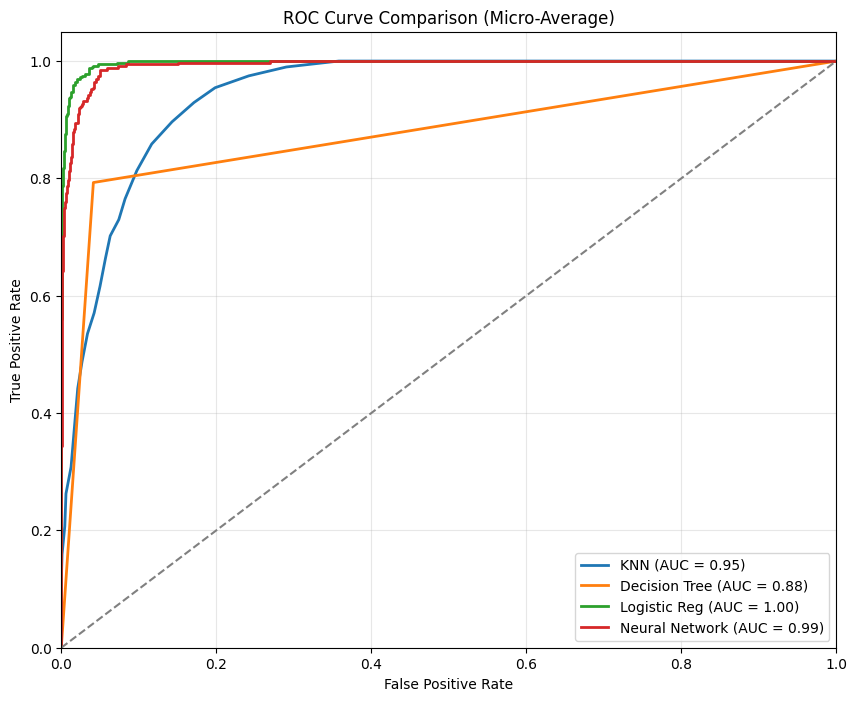

/tmp/ipython-input-3950928622.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=results_df, palette='viridis')


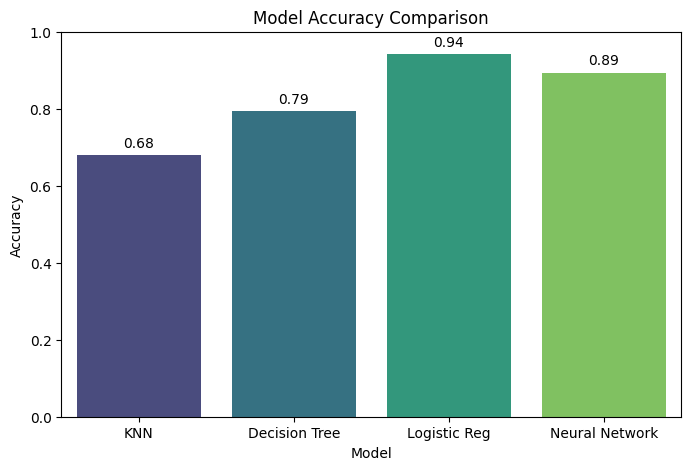

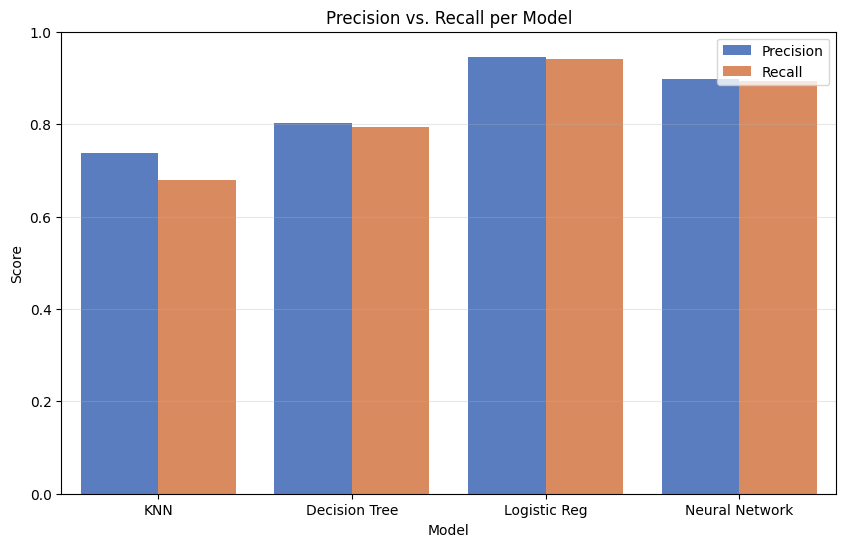

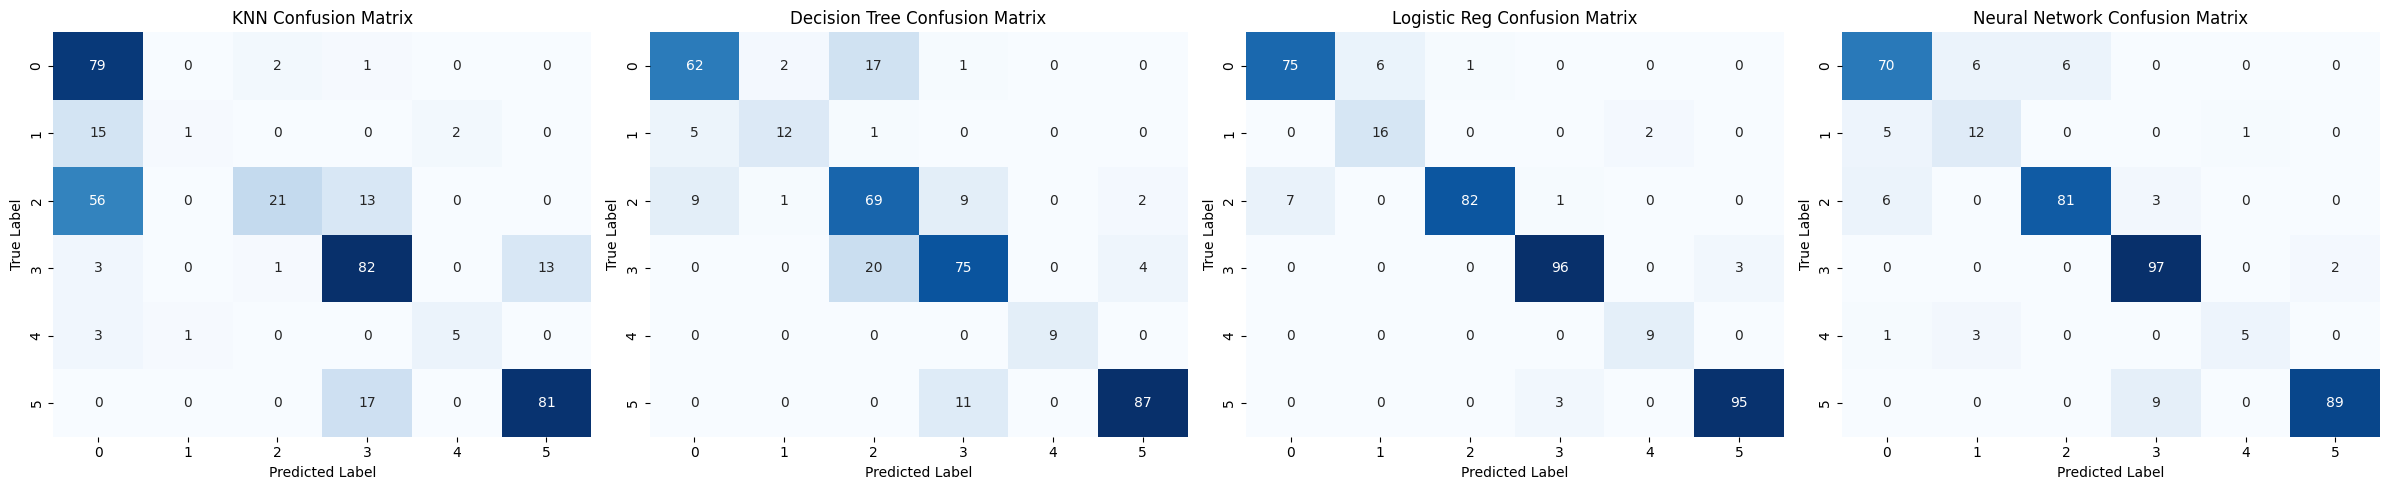


--- FINAL MODEL COMPARISON ---
         Model  Accuracy  Precision  Recall  F1 Score
           KNN    0.6793     0.7374  0.6793    0.6422
 Decision Tree    0.7929     0.8014  0.7929    0.7953
  Logistic Reg    0.9419     0.9455  0.9419    0.9428
Neural Network    0.8939     0.8978  0.8939    0.8941

🏆 The Best Performing Model is: Logistic Reg


In [ ]:
#15
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

# 1. Setup Models Dictionary
# We use the trained models from the previous step
models = {
    "KNN": model_knn,
    "Decision Tree": model_dt,
    "Logistic Reg": model_lr,
    "Neural Network": model_nn
}

# Initialize a list to store results for the report
results_list = []

# Prepare for ROC Curve (Binarize the target for multi-class ROC)
y_test_bin = label_binarize(y_test, classes=np.unique(y))
n_classes = y_test_bin.shape[1]

# ======================================================
# A. CALCULATE METRICS & GENERATE ROC CURVES
# ======================================================
plt.figure(figsize=(10, 8))

for name, model in models.items():
    # 1. Predict Classes
    y_pred = model.predict(X_test)

    # 2. Calculate Metrics
    acc = accuracy_score(y_test, y_pred)
    # Weighted average is used for multi-class problems to handle imbalance
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    # Store metrics
    results_list.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1
    })

    # 3. Predict Probabilities for ROC
    try:
        y_prob = model.predict_proba(X_test)
        # Compute Micro-Average ROC
        fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_prob.ravel())
        roc_auc = auc(fpr, tpr)

        # Plot ROC Curve for this model
        plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.2f})')
    except:
        print(f"Skipping ROC for {name} (probability prediction not supported)")

# Finalize ROC Plot
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison (Micro-Average)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# ======================================================
# B. BAR CHARTS (Accuracy, Precision, Recall)
# ======================================================
# Convert results to DataFrame
results_df = pd.DataFrame(results_list)

# 1. Accuracy Comparison
plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='Accuracy', data=results_df, palette='viridis')
plt.title('Model Accuracy Comparison')
plt.ylim(0, 1.0)
for index, row in results_df.iterrows():
    plt.text(index, row['Accuracy'] + 0.02, f"{row['Accuracy']:.2f}", ha='center')
plt.show()

# 2. Precision & Recall Grouped Bar Chart
# Reshape data for grouped plotting
results_melted = results_df.melt(id_vars="Model", value_vars=["Precision", "Recall"], var_name="Metric", value_name="Score")

plt.figure(figsize=(10, 6))
sns.barplot(x="Model", y="Score", hue="Metric", data=results_melted, palette="muted")
plt.title("Precision vs. Recall per Model")
plt.ylim(0, 1.0)
plt.legend(loc='upper right')
plt.grid(axis='y', alpha=0.3)
plt.show()

# ======================================================
# C. CONFUSION MATRICES
# ======================================================
fig, axes = plt.subplots(1, 4, figsize=(24, 5))

for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False)
    axes[i].set_title(f'{name} Confusion Matrix')
    axes[i].set_xlabel('Predicted Label')
    axes[i].set_ylabel('True Label')

plt.tight_layout()
plt.show()




# ======================================================
# D. FINAL SUMMARY TABLE
# ======================================================
print("\n--- FINAL MODEL COMPARISON ---")
print(results_df.round(4).to_string(index=False))

# Identification of the best model
best_model_name = results_df.loc[results_df['Accuracy'].idxmax()]['Model']
print(f"\n🏆 The Best Performing Model is: {best_model_name}")

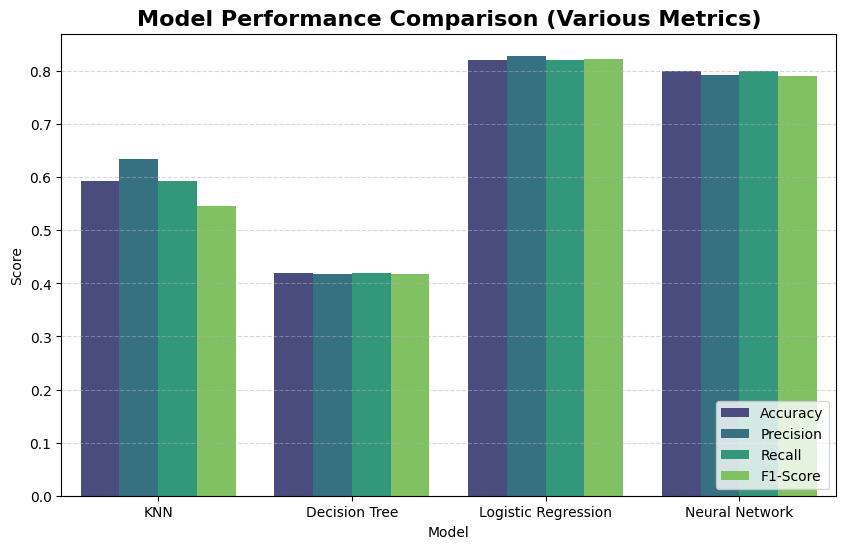

In [ ]:
#16

# ==========================================
# 1. PREPARE DATA (Assuming df is loaded or synthetic)
# ==========================================
# (For this example, we re-use the synthetic logic to ensure it runs anywhere)
np.random.seed(42)
X_syn = np.random.randint(1, 6, size=(2000, 30))
scores = X_syn.sum(axis=1) + np.random.normal(0, 2, 2000)
y_syn = np.digitize(scores, bins=[70, 80, 90, 100, 110])
X_train, X_test, y_train, y_test = train_test_split(X_syn, y_syn, test_size=0.2, random_state=42, stratify=y_syn)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================================
# 2. TRAIN MODELS
# ==========================================
models = {
    "KNN": KNeighborsClassifier(n_neighbors=25),
    "Decision Tree": DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42, class_weight='balanced'),
    "Neural Network": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
}

trained_models = {}
model_metrics = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    model_metrics.append({"Model": name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1-Score": f1})
    trained_models[name] = model

# ==========================================
# 3. PLOT: MULTI-METRIC COMPARISON
# ==========================================
df_metrics = pd.DataFrame(model_metrics)
df_melted = df_metrics.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(10, 6))
sns.barplot(data=df_melted, x="Model", y="Score", hue="Metric", palette="viridis")
plt.title("Model Performance Comparison (Various Metrics)", fontsize=16, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()